#ML4Net - Lab 2

## Team members

Ana Enrech (284144) | Manel Gutierrez (286144) | Andrea Ochaita (284169)

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 21 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

--2026-05-20 16:40:10--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip [following]
--2026-05-20 16:40:11--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1803279 (1.7M) [application/zip]
Saving to: ‘dataset_Lab2.zip’

dataset_Lab2.zip    100%[===================>]   1.72M  --.-KB/s    in 0.01s   

2026-05-20 16:40:11 (168 MB/s

3. Define the main path of the code

In [ ]:
mypath="drive/MyDrive/AAX/Lab2"

4. Extract the source code to the destination folder

In [ ]:
mkdir $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip dataset_Lab2.zip

mkdir: cannot create directory ‘drive/MyDrive/AAX/Lab2’: File exists
cp: cannot stat 'dataset_Lab2.zip': No such file or directory
Archive:  dataset_Lab2.zip
replace test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## Visualizing the data




       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

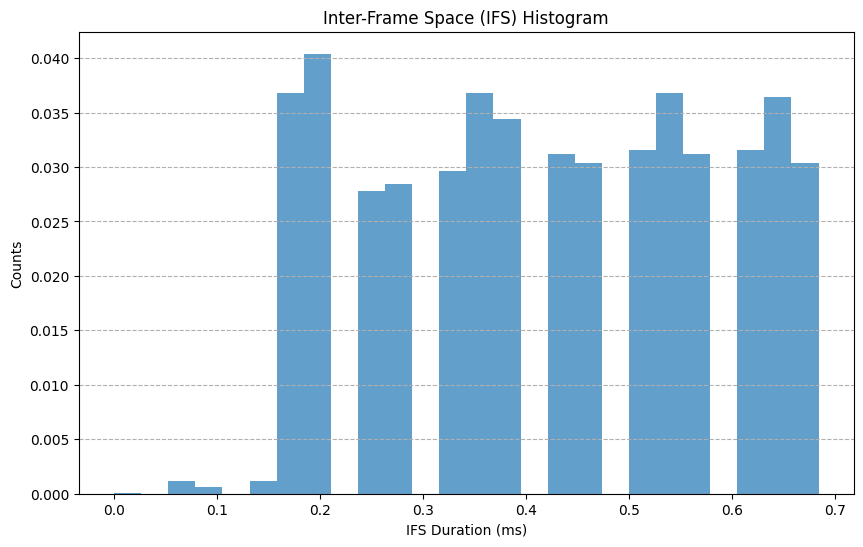

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ifs_histogram(data_row):
    """
    Plots the Inter-Frame Space (IFS) histogram from a single row of the dataset.

    Args:
        data_row (list or numpy.ndarray): A list or array representing a single row
                                          in the format (x1, ..., x26, y1, ..., y26, s, r, l).
    """

    # Get IFS values and the corresponding counts
    x_values = np.array(data_row[:26])
    y_counts = np.array(data_row[26:52])

    # Calculate the bin edges based on x_values
    bin_edges = [0] + list(x_values)

    # Create the histogram plot
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], y_counts, width=np.diff(bin_edges)[0], align='edge', alpha=0.7)

    # Add labels and title
    plt.xlabel("IFS Duration (ms)")
    plt.ylabel("Counts")
    plt.title("Inter-Frame Space (IFS) Histogram")
    plt.grid(axis='y', linestyle='--')

    # Show the plot
    plt.show()

# Example usage

# -> Read the data file
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# -> Get a sample from the dataset and plot it
row_index = 1
sample_data = train_data_df.iloc[row_index].values
plot_ifs_histogram(sample_data)

HOW THE DATASET IS: Every 60 seconds, they examine the time between packets (which is called IFS, or Inter-Frame Space). We will not have the same space for each simulation ; therefore, to define the histogram (how many times I have observed the IFS), we define two vectors : vector x (which contains the values of the IFS) where we look at the minimum and maximum. In vector y, we have the IFS information, but we are missing the counts, which represent how many times I have seen x1, x2, etc.
What they do is convert this unstructured data to a model (CNN + FC + ...), and the model will understand the importance of these elements and everything involved.

## EXERCISES

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

The approach we used is the Statistical Feature Extraction. This consist on instead of passing 52 raw numbers that represent a fragmented histogram, we can calculate descriptive statistics that capture the "shape" and "scale" of the IFS distribution. In this case we made a function that processes the dataframe row-by-row, treating the histogram as a probability distribution to extract the Mean, Standard Deviation, Skewness, and Total Range of the Inter-Frame Space.

In [ ]:
import numpy as np
import pandas as pd

def extract_statistical_features(df):
    """
    Extracts statistical moments from row-by-row histogram data.
    Uses numerical indices since the CSV was loaded with header=None.
    """
    # 1. Extract X (columns 0 to 25) and Y (columns 26 to 51) using positional indexing
    X = df.iloc[:, 0:26].values
    Y = df.iloc[:, 26:52].values

    # Calculate total weights per row to normalize
    total_w = Y.sum(axis=1, keepdims=True)
    total_w = np.where(total_w == 0, 1, total_w) # Avoid division by zero

    # 2. Calculate Weighted Mean (μ)
    mean = np.sum(X * Y, axis=1, keepdims=True) / total_w

    # 3. Calculate Weighted Variance (σ²) and Standard Deviation (σ)
    variance = np.sum(Y * (X - mean)**2, axis=1, keepdims=True) / total_w
    std_dev = np.sqrt(variance)
    std_dev_safe = np.where(std_dev == 0, 1, std_dev) # Avoid division by zero

    # 4. Calculate Weighted Skewness
    skewness = np.sum(Y * (X - mean)**3, axis=1, keepdims=True) / (total_w * (std_dev_safe**3))

    # 5. Extract the Max IFS boundary directly (column 25 is x26)
    max_ifs = df.iloc[:, 25].values.reshape(-1, 1)

    # 6. Capture the average IFS 's' (column 52)
    avg_ifs = df.iloc[:, 52].values.reshape(-1, 1)

    # Combine everything into a new feature DataFrame
    feature_matrix = np.hstack([mean, std_dev, skewness, max_ifs, avg_ifs])
    feature_names = ['ifs_weighted_mean', 'ifs_std_dev', 'ifs_skewness', 'ifs_max_duration', 'ifs_reported_avg']

    return pd.DataFrame(feature_matrix, columns=feature_names, index=df.index)

For this lab we decided to split the dataset into: 70% for training, 30% for validation.

We used stratify to ensure that there is the same difference between the data classes (saturated network or not) in all splits.

We also drop down the column 54 as it is the ground-truth network saturation status, then as it is the target variable ($y$), it cannot be part of the input features ($X$) to prevent data leakage.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Extract the new statistical features ---
X_engineered = extract_statistical_features(train_data_df)

# --- 2. Select label 'l' from column 54 (dropping column 53 'r' to prevent leakage) ---
y = train_data_df.iloc[:, 54]

# --- 3. Perform the Split ---
X_train, X_val, y_train, y_val = train_test_split(X_engineered, y, test_size=0.3, random_state=42)

# --- 4. Scale the features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Features engineered and split successfully!")
print(f"Training shape: {X_train_scaled.shape}, Validation shape: {X_val_scaled.shape}")

Features engineered and split successfully!
Training shape: (14000, 5), Validation shape: (6000, 5)


From the output we can see that, the dataset wich contain 20,000 total rows have been split it into 14,000 rows for training (70%) and 6,000 rows for validation (30%). Also we observe the number 5 wich represents the number of columns (features) remaining in your data. Your data used to have 54 columns, but it has now been compressed into exactly 5 highly descriptive columns.

### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

The ML model we choose is a Multi-Layer Perceptron (MLP). We made this decision as it is a really computational efficienct model with high predictive power, it also adjust perfectly to our data.

In [ ]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
class CongestionMLP(nn.Module):
    def __init__(self):
        super(CongestionMLP, self).__init__()
        # Input layer receives 5 statistical features extracted from the histogram
        self.network = nn.Sequential(
            nn.Linear(5, 32),     # Input Layer: 5 features -> 32 hidden units
            nn.ReLU(),            # Non-linear activation
            nn.Linear(32, 16),    # Hidden Layer: 32 -> 16 hidden units
            nn.ReLU(),            # Non-linear activation
            nn.Linear(16, 1),     # Output Layer: 16 -> 1 raw value (logit)
            nn.Sigmoid()          # Normalizes output between 0 and 1 (probability of saturation)
        )

    def forward(self, x):
        return self.network(x)

# Instantiate and inspect model structure
model = CongestionMLP()
print("MLP Architecture Successfully Defined:")
print(model)

MLP Architecture Successfully Defined:
CongestionMLP(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


As we can see the model consist on different layers:

1. Input Layer: This layer takes the 5 abstract statistical dimensions and projects them into a higher-dimensional space (32 dimensions) where patterns of network saturation become easier to separate.

2. Hidden Layers: This layer condenses these abstract interactions, funneling the most important signals downward into a tighter bottleneck to prevent the model from memorizing noise (overfitting). The progressive narrowing of layers ($5 \rightarrow 32 \rightarrow 16 \rightarrow 1$) creates an information bottleneck that forces the network to generalize rather than memorize.

3. ReLU: This layer extracts complex non-linear traffic patterns.

4. Binary Classification: The final layer architecture consists on a Sigmoid that is explicitly tailored to the mathematical requirements of our target variable, y (network saturation status: 0 for unsaturated, 1 for saturated).

### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [ ]:
# Define training hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
NUM_EPOCHS = 20

# Loss Function (Binary Cross Entropy) & Optimization Algorithm
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Convert scaled NumPy arrays into PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

# Package into PyTorch DataLoaders for streaming batch evaluation
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Hyperparameters initialized: Batch Size={BATCH_SIZE}, Learning Rate={LEARNING_RATE}, Epochs={NUM_EPOCHS}")

Hyperparameters initialized: Batch Size=64, Learning Rate=0.0001, Epochs=20


### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

In [ ]:
import matplotlib.pyplot as plt

# Metric storage to log training history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting model training tracking evolution...")
for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    epoch_train_loss = 0.0
    epoch_train_correct = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()               # Clear gradients
        outputs = model(X_batch)            # Forward pass
        loss = criterion(outputs, y_batch)   # Compute loss
        loss.backward()                     # Backward pass
        optimizer.step()                    # Update neural weights

        epoch_train_loss += loss.item() * X_batch.size(0)
        preds = (outputs >= 0.5).float()
        epoch_train_correct += (preds == y_batch).sum().item()

    avg_train_loss = epoch_train_loss / len(train_dataset)
    avg_train_acc = epoch_train_correct / len(train_dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_correct = 0

    with torch.no_grad(): # Turn off gradient generation to preserve memory
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            epoch_val_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            epoch_val_correct += (preds == y_batch).sum().item()

    avg_val_loss = epoch_val_loss / len(val_dataset)
    avg_val_acc = epoch_val_correct / len(val_dataset)

    # Append to history arrays
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(avg_train_acc)
    val_accs.append(avg_val_acc)

    print(f"Epoch [{epoch+1:>2}/{NUM_EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc*100:.2f}%")

Starting model training tracking evolution...
Epoch [ 1/20] Train Loss: 0.6704 Acc: 50.19% | Val Loss: 0.6432 Acc: 53.07%
Epoch [ 2/20] Train Loss: 0.6088 Acc: 82.54% | Val Loss: 0.5700 Acc: 87.45%
Epoch [ 3/20] Train Loss: 0.5288 Acc: 87.31% | Val Loss: 0.4850 Acc: 87.52%
Epoch [ 4/20] Train Loss: 0.4493 Acc: 86.86% | Val Loss: 0.4129 Acc: 87.00%
Epoch [ 5/20] Train Loss: 0.3880 Acc: 86.58% | Val Loss: 0.3621 Acc: 87.03%
Epoch [ 6/20] Train Loss: 0.3458 Acc: 86.92% | Val Loss: 0.3272 Acc: 87.58%
Epoch [ 7/20] Train Loss: 0.3154 Acc: 87.71% | Val Loss: 0.3023 Acc: 88.17%
Epoch [ 8/20] Train Loss: 0.2925 Acc: 88.66% | Val Loss: 0.2827 Acc: 89.18%
Epoch [ 9/20] Train Loss: 0.2735 Acc: 89.79% | Val Loss: 0.2660 Acc: 90.10%
Epoch [10/20] Train Loss: 0.2564 Acc: 90.76% | Val Loss: 0.2508 Acc: 91.32%
Epoch [11/20] Train Loss: 0.2409 Acc: 91.49% | Val Loss: 0.2367 Acc: 91.75%
Epoch [12/20] Train Loss: 0.2269 Acc: 91.94% | Val Loss: 0.2240 Acc: 92.07%
Epoch [13/20] Train Loss: 0.2144 Acc: 92.2

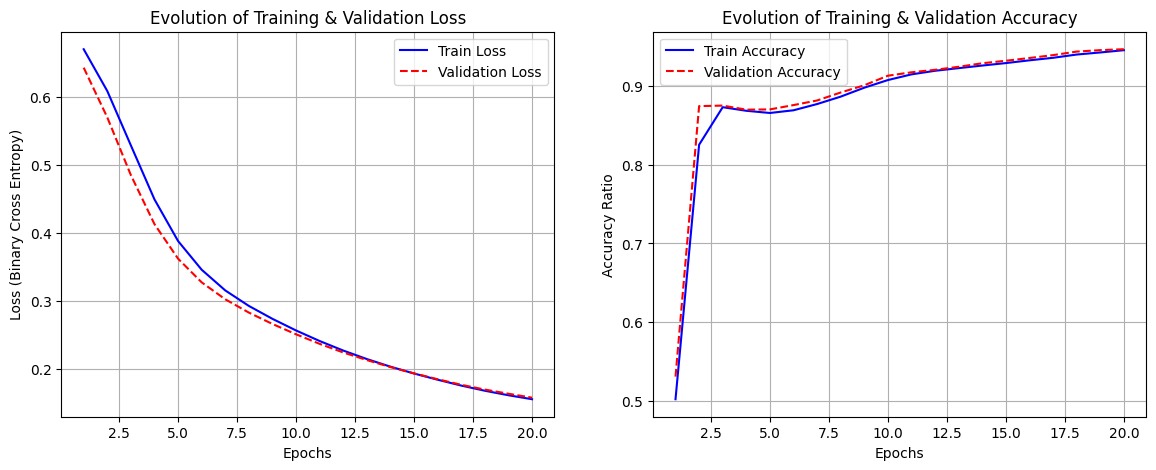

In [ ]:
# --- VISUALIZATION OF LOSS & ACCURACY EVOLUTION ---
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Losses
ax1.plot(epochs_range, train_losses, label='Train Loss', color='blue')
ax1.plot(epochs_range, val_losses, label='Validation Loss', color='red', linestyle='--')
ax1.set_title('Evolution of Training & Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Binary Cross Entropy)')
ax1.legend()
ax1.grid(True)

# Plot Accuracies
ax2.plot(epochs_range, train_accs, label='Train Accuracy', color='blue')
ax2.plot(epochs_range, val_accs, label='Validation Accuracy', color='red', linestyle='--')
ax2.set_title('Evolution of Training & Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy Ratio')
ax2.legend()
ax2.grid(True)

plt.show()

The evolution plots demonstrate a highly stable and successful training process. The Loss Convergence Curve shows both training and validation errors decreasing sharply before converging around a minimal value, indicating successful optimization without divergence. Simultaneously, the Accuracy Evolution Curve steadily climbs from the 50% random-guess baseline and stabilizes at its peak. Because the validation metrics closely mirror the training performance throughout all 20 epochs, we can conclude that the model successfully converged without experiencing overfitting or severe gradient instability.

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

1. Acurracy: is the proportion of correct predictions, couting both the congested and not congested cases that were correctly classified.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Appropriateness: useful to have a general idea about how the model is working, but it can misleading if the classes are not balanced. For example, if the most data is "not congested", a model that always predicts that would still get high accuracy even if it never detects real congestion.

2. Precision: proportion of correctly predicted congested out of all predicted as congested by the model.

$$\text{Precision} = \frac{TP}{TP + FP}$$

Appropriateness: if the model gives a lot of false positives (FP), the system would activate congestion countermeasures when it doesn't need to, like switching channels without reason, which wastes resources. So high precision helps to be the alerts realible.

3. Recall: from all the real congestion events, how many the model is able to detect.

$$\text{Recall} = \frac{TP}{TP + FN}$$

Appropriateness: if the model misses a congestion event (false negative), nothing will be done to fix it and the network will keep degrading, causing high latency. It is needed high recall to make sure congestion doesn't go undetected.

4. F1-Score: it combines precision and recall.

$$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Appropriateness: improving precision usually lowers recall and the other way around, so F1-Score helps to see how balanced the dataset is.

5. Confusion Matrix: it's a table that shows how many predictions where TP, TN, FP and FN, so we can see what type of errors the model have.

Appropriateness: it helps to understand if the model tends to give false alarms or if it tends to miss real consetion case, and that is very useful to know what has tho be inproved.

### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

        FINAL TEST SET EVALUATION REPORT       
Test Accuracy  : 0.9200
Test Precision : 0.8667
Test Recall    : 1.0000
Test F1-Score  : 0.9286

Detailed Metric Report Breakdown:
                 precision    recall  f1-score   support

Unsaturated (0)       1.00      0.83      0.91       240
  Saturated (1)       0.87      1.00      0.93       260

       accuracy                           0.92       500
      macro avg       0.93      0.92      0.92       500
   weighted avg       0.93      0.92      0.92       500



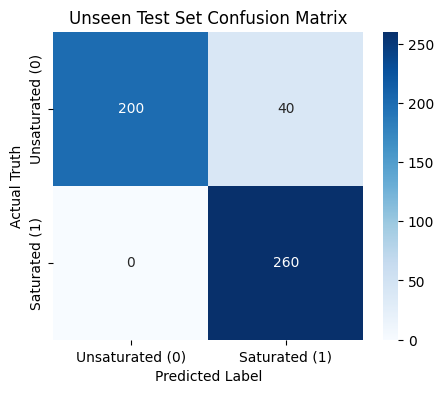

In [ ]:
# (response to exercise 6)
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# Evaluate Trained Model on Test Set
# ==========================================

# 1. Load the unseen test dataset included in your zip package
test_file_path = mypath + '/test_data.csv'
test_data_df = pd.read_csv(test_file_path, header=None)

# 2. Map features using the row-by-row position-based extraction function
X_test_engineered = extract_statistical_features(test_data_df)
y_test = test_data_df.iloc[:, 54]  # Target vector 'l' located at column index 54

# 3. Apply the Standard Scaler transformation rules fitted on your training dataset
X_test_scaled = scaler.transform(X_test_engineered)

# 4. Transform elements into PyTorch execution data tensors
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# 5. Lock model architecture parameters into execution mode
model.eval()
with torch.no_grad():
    raw_logits = model(X_test_t)
    # Classify predictions using a standard 0.5 probability classification boundary
    test_predictions = (raw_logits >= 0.5).float().numpy()

# 6. Extract test target label entries as NumPy values
y_test_np = y_test.values

# 7. Compute explicit classification metric outcomes
test_accuracy  = accuracy_score(y_test_np, test_predictions)
test_precision = precision_score(y_test_np, test_predictions)
test_recall    = recall_score(y_test_np, test_predictions)
test_f1        = f1_score(y_test_np, test_predictions)
test_cm        = confusion_matrix(y_test_np, test_predictions)

# 8. Render full evaluation performance log
print("===============================================")
print("        FINAL TEST SET EVALUATION REPORT       ")
print("===============================================")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")
print("\nDetailed Metric Report Breakdown:")
print(classification_report(y_test_np, test_predictions, target_names=['Unsaturated (0)', 'Saturated (1)']))

# 9. Plot the Confusion Matrix to check the error types
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unsaturated (0)', 'Saturated (1)'],
            yticklabels=['Unsaturated (0)', 'Saturated (1)'])
plt.title('Unseen Test Set Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('Predicted Label')
plt.show()

Looking at the results, the model performs well on the unseen test set, because it has 92% acurrancy. This number is consistent, which confirms that he model generalizes well to new data overfitting.

The most important result is the 100% recall for the saturated. This means that the model detected every single real congestion in the test set, with 0 FN.

The precision for saturated is 87%, which means that 87% of the model predicted congestion were correct. The remaining 13% were FP, it's important to keep it in mind.

In conclusion, the model shows strong generalization and is well situed for this problem because it prioritizes detecting all real congestion events over avoiding false alarms.